<a href="https://colab.research.google.com/github/BenjaminJones-lccc/Week-15-AIML/blob/main/Week_15_(Traffic_Sign_Recognition)_Student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Traffic Sign Recognition

# The Scenario

"More than 38,000 people die every year in crashes on U.S. roadways. The U.S. traffic fatality rate is 12.4 deaths per 100,000 inhabitants. An additional 4.4 million are injured seriously enough to require medical attention." <br>

This brings with it the utmost importance to introduce autonomous vehicles to keep the people safe. <br>
However, to truly keep the people safe, the vehicles must be able to recognize the traffic signs and act accordingly. <br>

You are an AI Engineer with DriveSafe, a company that focuses on building autonomous vehicles.<br>
Your current task is to train the vehicles to recognize the traffic signs.<br>

Source: https://www.asirt.org/safe-travel/road-safety-facts/


# Tips for working on this project
You will be using these three concepts to be able to successfully complete this project:
1. Deep Learning models
2. AI Project Cycle <br>
3. AI Ethics <br>

If needed, please revise your notes on these topics.

# Section 1: Understand the Problem

One of the key points of solving an AI problem is to understand the problem statement correctly. <br>
You need to understand what is the correct problems that you are solving.<br>
You want to solve the root problem and not the symptoms.<br>
To do that, you can use tools like 5 Whys, decomposition, and Fish-bone diagram.<br>
You can then write your problem statement.<br>
It may include helpful information, like who is affected, what is the problem, where is it happening, and when does it happen.<br>

Based on the scenario above, write your problem statement in the cell below.<br>

In [ ]:
# Your answers here!



High traffic fatalities nowadays are due to the introduction of autonomous vehicles on the road. To prevent further accidents, we should have these cars equipped with computer vision models, capable of detecting and classifying traffic signs in real time.

# Section 2: Data Acquisition

Data is the main ingredient for AI model. <br>
For a typical scenario for autonomous vehicles, where can you find your data? <br>
Write your answer in the cell below. <br>

In this scenario, you are given a few files.<br>
These files are downloaded from: https://www.kaggle.com/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign <br>


data for these vehicles can be acquired from open-source datasets like Cityscapes. Things such as dashcams would collect real time footage and could help simulate realistic environments to generate scenarios.

In [ ]:
# Your answers here!


## The AI Ethics of Handling Data
AI Ethics are a vital component in our daily life. <br>
What areas of AI Ethics are important in this scenario? <br>
What are the implications of ignoring AI Ethics? <br>
More importantly, what can you do to uphold AI Ethics in this scenario? <br>
Write your answer in the cell below.

Important areas of AI Ethics is ensuring the model works with any sort of variable, whether it be the weather, temperature, ligthing, and terrain.

The unfortunate implications of ignoring such things could  missclasifying signs. Such as a do not enter to a four way intersection as opposed to traffic lights or a stop sign.

We can uphold Ai Ethics by ensuring that the dataset being trained is diverse in scenarios and weather conditions. It should be texted to its' upmost and maybe even a failsafe mechanism if the AI can't predict a positive outcome.

In [ ]:
# Your answer here!


In order to make this model safe, it MUST work. this involves testing it in any sort of situation such as terrain, different lighting, weather, and various signs which is the focus of the Computer model.

# Import libraries and insert the file

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from PIL import Image
import os
from sklearn.model_selection import train_test_split

# Uncomment the below if your tensorflow is 1.x
# from keras.utils import to_categorical
# from keras.models import Sequential, load_model
# from keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

# Uncomment the below if your tensorflow is 2.x
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dense, Flatten, Dropout

# Section 3: Data Exploration
Let's prepare the data so that it's ready for the modeling.

In [3]:
# Let's initialize some variables
import os
data = []
labels = []
classes = 43
current_path = '/content'

In [4]:
!unzip -q "[Dataset]_TrafficSign.zip"

replace Meta.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
N


In [5]:
from posixpath import join
# Retrieve the images and their labels
for i in range(classes):
    path = os.path.join(current_path,'Train',str(i))
    images = os.listdir(path)

    for a in images:
        try:
            img_path = os.path.join(path,a)
            image = Image.open(img_path)
            image = image.resize((30,30))
            image = np.array(image)
            data.append(image)
            labels.append(i)
        except:
            print("Error loading image")

## Train Test Split
Do you still remember how to split your data into training data and testing data? <br>
For easy reference, you need to create: X_train, X_test, y_train, y_test <br>

What ratio will you use to do the split? <br>
Common ratios are 70:30 and 80:20.

In [6]:
# Convert lists into numpy arrays
data = np.array(data)
labels = np.array(labels)

print(data.shape, labels.shape)

# Your answers here!
#Split into training data and testing data
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

(39209, 30, 30, 3) (39209,)


## One Hot Encoding

Usually, numbers in Machine Learning algorithms mean ranking or importance. <br>
However, some input data do not have any ranking. This may lead to poor predictions. <br>
Therefore, we need to use one hot encoding to solve the above problem. <br>
Do you still remember how to do that? <br>
Write your answer in the cell below.

In [7]:
# Your answers here!
# Convert the labels into one hot encoding
y_train = to_categorical(y_train, classes)
y_test = to_categorical(y_test, classes)


# Section 4: Modeling
We will be building our Neural Network. <br>
Do you still remember how it looks like? <br>

There are different layers, each with different purposes:
1. Conv2D : it is a 2D convolution layer to produce a tensor of outputs.
2. MaxPool2D : it reduces the size by sampling the maximum value in the region.
3. Dropout : it drops some neural network connections to prevent overfitting. <br>

In the cell below, create your own Neural Network model. <br>
You can experiment by mixing layers of Conv2D, MaxPool2D, and Dropout, of varying parameters.

In [8]:
# Your answers here!

#Build the model
model = Sequential()


model.add(Conv2D(filters=32, kernel_size=(5,5), activation='relu', input_shape=(30, 30, 3)))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

model.add(Conv2D(filters=64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPool2D(pool_size=(2, 2)))
model.add(Dropout(rate=0.25))

model.add(Flatten())
model.add(Dense(256, activation='relu'))
model.add(Dropout(rate=0.5))

model.add(Dense(classes, activation='softmax'))















/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Compilation
You will need to determine what is the metrics for your model. <br>
You've learned about binary_crossentropy and categorical_crossentropy. <br>
You've also learned about the different optimizers (ADAM, SGD, etc).

In [9]:
# Your answers here!
# Compile the model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

## How long do you want to train your model?
You can determine how many cycles you want to run. <br>
In Machine Learning, a cycle is called an epoch. <br>
Theoretically, the more epoch will lead to higher acuracy. However, it may lead to overfitting. <br>
You can also determine the size of each batch. The bigger the batch size, the more data it will be tested at one time. <br>
However, it will be more taxing on your computing resources too. <br>

In the cell below, indicate your epoch, batch_size, and the code for model.fit().

In [10]:
# Your answers here!
epochs = 20
batch_size = 32

history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_test, y_test))


Epoch 1/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 35s 34ms/step - accuracy: 0.3080 - loss: 3.0449 - val_accuracy: 0.6445 - val_loss: 1.2627
Epoch 2/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.6084 - loss: 1.3031 - val_accuracy: 0.8409 - val_loss: 0.6372
Epoch 3/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.7173 - loss: 0.9387 - val_accuracy: 0.9054 - val_loss: 0.4435
Epoch 4/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 28s 28ms/step - accuracy: 0.7618 - loss: 0.7759 - val_accuracy: 0.9221 - val_loss: 0.3142
Epoch 5/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 28s 29ms/step - accuracy: 0.7963 - loss: 0.6785 - val_accuracy: 0.9320 - val_loss: 0.2540
Epoch 6/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.8088 - loss: 0.6342 - val_accuracy: 0.9357 - val_loss: 0.2507
Epoch 7/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 41s 29ms/step - accuracy: 0.8218 - loss: 0.6062 - val_accuracy: 0.9401 - val_loss: 0.2207
Epoch 8/20
981/981 ━━━━━━━━━━━━━━━━━━━━ 29s 30ms/step - accuracy: 0.8366 - loss: 0.5529 - 

# Section 5: Evaluation
We want to check the performance of our model. <br>
We want to know the accuracy of the results. <br>
Do you know how to identify underfitting and overfitting (if any) from the below graphs?

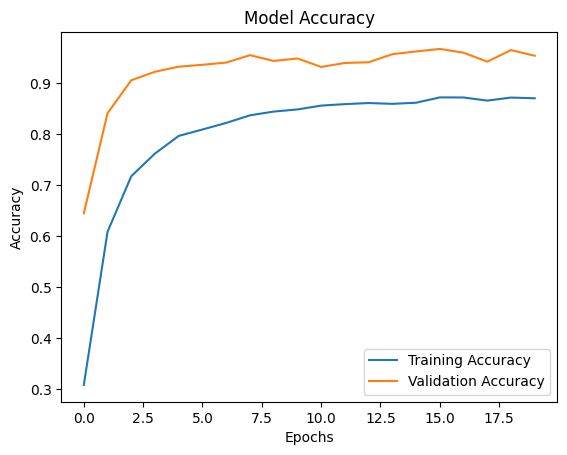

In [11]:
# Your answers here!

# plot the graph for accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()







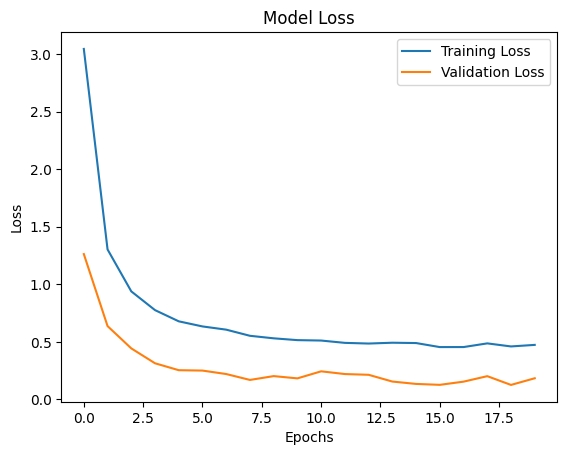

In [12]:
# Your answers here!

# plot the graph for loss

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()






## Evaluate using Test Dataset
Just now, we evaluated the model using the data from the training dataset. <br>
Now, we will evaluate using Test.csv, which is the data that the model has never seen before.

In [13]:
# test accuracy on test dataset
from sklearn.metrics import accuracy_score

y_test = pd.read_csv('Test.csv')

labels = y_test["ClassId"].values
imgs = y_test["Path"].values

data=[]

In [14]:
for img in imgs:
    image = Image.open(img)
    image = image.resize((30,30))
    data.append(np.array(image))

X_test=np.array(data)

pred = np.argmax(model.predict(X_test), axis=-1)

395/395 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


## Check accuracy
Use accuracy_score from sklearn.metrics to compare the score between the actual labels and predictions.

In [15]:
# Your answers here!
# Accuracy with the test data
print("Test Data Accuracy:", accuracy_score(labels, pred))


Test Data Accuracy: 0.9010292953285828


# What is your best model?
In order to get the best model, you will need to modify the parameters. <br>
Look back at the models in section 4, can you fine-tune them better? <br><br>
What is your best model? How does it fare?

# Section 6: Deployment
What makes a good deployment? <br>
It has to be useful and easy to use. <br>
It needs to be updated frequently and easily.<br>
Deployment can be on-premise or online.<br>

In the cell below, write down your suggestions on how you can deploy this AI model.

In [ ]:
# Your answers here!

# Since this is used on autonomous vehicle, it will be used in the embedded system of the car.
# The camera feeds from the camera will be captured and analyzed by the model directly.

You should deploy the model on embedded systems within the vehicle. This SHOULD allow for some low-latency without using internet connectivity...which could really get someone hurt. The manufacturer should use something called Over The Air updates to push new and improved models to the car's system while connected to wifi.

# Other Reading Materials
You can get more info through these materials: <br>
